In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maimaumme/bangla-cyberbullying/pattern lab dataset.xlsx


# Libraries

In [57]:
# Basic libraries
import os
import numpy as np
import pandas as pd


# Inter-rater agreement
from statsmodels.stats.inter_rater import fleiss_kappa

# Train-test split & label encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Optional: metrics for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dataset Collection & Load

In [58]:
# Load dataset
file_path = '/kaggle/input/datasets/maimaumme/bangla-cyberbullying/pattern lab dataset.xlsx'
df = pd.read_excel(file_path)

# Inspect dataset
df.head()

,Unnamed: 0,Description,Label,Annotation 1,Annotation 2,Annotation 3
0,0.0,ওই হালার পুত এখন কি মদ খাওয়ার সময় রাতের বেলা...,sexual,sexualized vulgar,sexualized vulgar,Sexualized Vulgar
1,1.0,আপনার জন্ম প্রক্রিয়ার সময় আপনার মায়ের ভিতর কি ...,sexual,Sexualized Vulgar,Sexualized Vulgar,Sexualized Vulgar
2,2.0,বোকাচোদা একটা।,sexual,Personal Attack,Personal Attack,Personal Attack
3,3.0,নিজের রিভিউ বারানোর জন্যই জতো সব নাটক? ফালতু.....,sexual,Personal Attack,Personal Attack,Personal Attack
4,4.0,আমাদের দেশের পোলাপাইনদের কোন কাজকাম নাই মনে ...,sexual,sexualized vulgar,sexualized vulgar,sexualized vulgar


# Subclass Design & Preprocessing

In [59]:
# Rename annotation columns
df = df.rename(columns={
    'Annotation 1': 'annotator1',
    'Annotation 2': 'annotator2',
    'Annotation 3': 'annotator3'
})

# Standardize text
for col in ['annotator1', 'annotator2', 'annotator3']:
    df[col] = df[col].str.lower().str.strip()

# Drop rows with missing labels
df = df.dropna()

# -------------------------------
# 🔥 Noise Removal (ADD HERE)
# -------------------------------

annotator_cols = ['annotator1', 'annotator2', 'annotator3']

def agreement_score(row):
    labels = [row[col] for col in annotator_cols]
    return len(set(labels))

df['agreement'] = df.apply(agreement_score, axis=1)

# Keep rows where at least 2 annotators agree
df = df[df['agreement'] <= 2].copy()

# Reset index
df = df.reset_index(drop=True)

print("After noise removal:", len(df))


# -------------------------------
# Your subclasses (keep as is)
# -------------------------------
subclasses = [
    'sexualized vulgar', 'sexual objectification', 'personal attack', 'sexualized slur',
    'violent', 'indirect threat', 'direct threat',
    'political criticism', 'political insult', 'political accusation', 'political threat',
    'provocation', 'opinionated', 'insulting', 'sarcasm',
    'neutral inquiry', 'information', 'appreciate', 'supportive', 'positive', 'advice', 'opinion'
]

After noise removal: 1020


# Label Quality Check (Fleiss Kappa)

In [62]:
# Build matrix for Fleiss Kappa
matrix = []
for _, row in df.iterrows():
    counts = [0] * len(subclasses)
    labels = [row['annotator1'], row['annotator2'], row['annotator3']]
    for label in labels:
        if label in subclasses:
            idx = subclasses.index(label)
            counts[idx] += 1
    matrix.append(counts)

matrix_df = pd.DataFrame(matrix, columns=subclasses)

import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa

# ---- Identify problematic rows ----
problem_rows = matrix_df[matrix_df.sum(axis=1) != 3]

print("Number of problematic rows:", len(problem_rows))
print(problem_rows)

# ---- Drop problematic rows ----
matrix_df = matrix_df[matrix_df.sum(axis=1) == 3].reset_index(drop=True)

# ---- Verify ----
print("\nAfter cleaning:")
print("Remaining rows:", len(matrix_df))
print("Row sums:", matrix_df.sum(axis=1).unique())

# ---- Compute Fleiss Kappa ----
kappa = fleiss_kappa(matrix_df.values)
print("\nFleiss Kappa:", kappa)

Number of problematic rows: 2
     sexualized vulgar  sexual objectification  personal attack  \
40                   0                       0                0   
156                  0                       0                0   

     sexualized slur  violent  indirect threat  direct threat  \
40                 0        0                0              0   
156                0        0                0              0   

     political criticism  political insult  political accusation  ...  \
40                     0                 0                     0  ...   
156                    0                 0                     0  ...   

     opinionated  insulting  sarcasm  neutral inquiry  information  \
40             0          0        0                0            0   
156            0          0        0                0            0   

     appreciate  supportive  positive  advice  opinion  
40            0           0         0       0        0  
156           0           0

# Majority Voting (Final Label)

In [63]:
# Function to assign final label using majority vote
def majority_vote(row):
    labels = [row['annotator1'], row['annotator2'], row['annotator3']]
    return max(set(labels), key=labels.count)

# Apply function
df['final_label'] = df.apply(majority_vote, axis=1)

# Check first 5 rows
df[['Description', 'final_label']].head()

,Description,final_label
0,ওই হালার পুত এখন কি মদ খাওয়ার সময় রাতের বেলা...,sexualized vulgar
1,আপনার জন্ম প্রক্রিয়ার সময় আপনার মায়ের ভিতর কি ...,sexualized vulgar
2,বোকাচোদা একটা।,personal attack
3,নিজের রিভিউ বারানোর জন্যই জতো সব নাটক? ফালতু.....,personal attack
4,আমাদের দেশের পোলাপাইনদের কোন কাজকাম নাই মনে ...,sexualized vulgar


# Merge Rare Labels

In [64]:
df['final_label'] = df['final_label'].replace({
    'sexualized vulger': 'sexualized vulgar',
    'sxualized vulgar': 'sexualized vulgar'
})

In [65]:
df['final_label'].unique()
df['final_label'].value_counts()

final_label
sexualized vulgar         157
insulting                  93
sarcasm                    80
positive                   69
violent                    60
supportive                 50
appreciate                 50
opinion                    49
provocation                45
personal attack            45
political insult           45
neutral inquiry            39
opinionated                38
sexual objectification     31
political criticism        31
political accusation       24
information                22
indirect threat            22
advice                     22
direct threat              19
sexualized slur            17
political threat           12
Name: count, dtype: int64

In [69]:
# -------------------------------
# 🔥 Class Merging (Academic Style Labels)
# -------------------------------

merge_map = {
    # Sexual 
    'sexualized vulgar': 'sexual',
    'sexual objectification': 'sexual',
    'sexualized slur': 'sexual',
    'personal attack': 'sexual',

    # Threat 
    'violent': 'threat',
    'direct threat': 'threat',
    'indirect threat': 'threat',

    # Political 
    'political insult': 'political',
    'political criticism': 'political',
    'political accusation': 'political',
    'political threat': 'political',

    # Troll
    'insulting': 'troll',
    'provocation': 'troll',
    'sarcasm': 'troll',
    'opinionated': 'troll',

    # Neutral 
    'neutral inquiry': 'neutral',
    'information': 'neutral',
    'opinion': 'neutral',
    'advice': 'neutral',
    'positive': 'neutral',
    'supportive': 'neutral',
    'appreciate': 'neutral'
}

# Apply mapping
df['final_label'] = df['final_label'].replace(merge_map)

# Check distribution
print(df['final_label'].value_counts())

final_label
neutral      301
troll        256
sexual       250
political    112
threat       101
Name: count, dtype: int64


# Train / Validation / Test Split, Encode & Save

In [70]:
# ==========================================
# FULL PIPELINE AFTER LABEL MERGING
# (Clean + Final Version)
# ==========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. LABEL ENCODING (AFTER MERGING)
# ==========================================
le = LabelEncoder()
df['label'] = le.fit_transform(df['final_label'])

print("📊 Class Mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# ==========================================
# 2. STRATIFIED TRAIN / VAL / TEST SPLIT
# ==========================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label']
)

# ==========================================
# 3. RESET INDEX (CLEAN DATAFRAMES)
# ==========================================
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ==========================================
# 4. BASIC INFO CHECK
# ==========================================
print("\n📊 Dataset Split:")
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\n🧾 Final Classes:")
print(le.classes_)

# ==========================================
# 5. SAVE DATASETS (OPTIONAL FOR KAGGLE)
# ==========================================
train_df.to_excel("/kaggle/working/train.xlsx", index=False)
val_df.to_excel("/kaggle/working/validation.xlsx", index=False)
test_df.to_excel("/kaggle/working/test.xlsx", index=False)

print("\n✅ Files saved: train.xlsx, validation.xlsx, test.xlsx")

📊 Class Mapping:
{'neutral': np.int64(0), 'political': np.int64(1), 'sexual': np.int64(2), 'threat': np.int64(3), 'troll': np.int64(4)}

📊 Dataset Split:
Train size: 734
Validation size: 82
Test size: 204

🧾 Final Classes:
['neutral' 'political' 'sexual' 'threat' 'troll']

✅ Files saved: train.xlsx, validation.xlsx, test.xlsx


# Label Statistics

In [71]:
# ==========================================
# CELL: Dataset Statistics Table (UPDATED)
# ==========================================

import pandas as pd

# Classes (from current merged dataset)
classes = sorted(df['final_label'].unique())

data = []

for cls in classes:
    
    # Train / Test counts (safe filtering)
    train_count = len(train_df[train_df['final_label'] == cls])
    val_count   = len(val_df[val_df['final_label'] == cls])
    test_count  = len(test_df[test_df['final_label'] == cls])
    
    # Total words per class (from FULL dataset)
    total_words = df[df['final_label'] == cls]['Description'].astype(str).apply(lambda x: len(x.split())).sum()
    
    data.append([cls, train_count, val_count, test_count, total_words])

# Create DataFrame
stats_df = pd.DataFrame(
    data,
    columns=["Class", "Train", "Validation", "Test", "Total Words"]
)

# Add total row
total_row = pd.DataFrame([[
    "TOTAL",
    stats_df["Train"].sum(),
    stats_df["Validation"].sum(),
    stats_df["Test"].sum(),
    stats_df["Total Words"].sum()
]], columns=stats_df.columns)

stats_df = pd.concat([stats_df, total_row], ignore_index=True)

# Show result
print("📊 Dataset Statistics:\n")
print(stats_df.to_string(index=False))

📊 Dataset Statistics:

    Class  Train  Validation  Test  Total Words
  neutral    217          24    60         2885
political     80           9    23         2360
   sexual    180          20    50         2644
   threat     73           8    20          814
    troll    184          21    51         4517
    TOTAL    734          82   204        13220


# Separate Features and Labels

In [74]:
# ==========================================
# FEATURES + LABELS SPLIT (FINAL CLEAN VERSION)
# ==========================================

# Ensure no missing values (safe practice)
train_df = train_df.dropna(subset=['Description', 'label'])
val_df   = val_df.dropna(subset=['Description', 'label'])
test_df  = test_df.dropna(subset=['Description', 'label'])

# Separate features and labels
X_train = train_df['Description'].astype(str)
y_train = train_df['label']

X_val = val_df['Description'].astype(str)
y_val = val_df['label']

X_test = test_df['Description'].astype(str)
y_test = test_df['label']

# ==========================================
# QUICK CHECK
# ==========================================
print("📊 Dataset Sizes:")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\n🧾 Label Distribution (Train):")
print(y_train.value_counts())

📊 Dataset Sizes:
Training samples: 734
Validation samples: 82
Test samples: 204

🧾 Label Distribution (Train):
label
0    217
4    184
2    180
1     80
3     73
Name: count, dtype: int64


In [64]:
df.to_csv('/kaggle/working/final_labeled_dataset.csv', index=False)

# Compute Class Weights

In [75]:
# ==========================================
# CLASS WEIGHTS (SAFE VERSION)
# ==========================================

import numpy as np
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert labels safely
y_train_np = np.array(y_train)

# Compute class weights
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)

print("Raw class weights:", class_weights_np)

# Convert to tensor (SAFE FIX)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

# Loss function
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# ==========================================
# OUTPUT CHECK
# ==========================================
print("\nClass Weights Tensor:")
print(class_weights)

print("\nClass Mapping:")
for cls, w in zip(np.unique(y_train_np), class_weights.cpu().numpy()):
    print(f"Class {cls} -> Weight {w:.4f}")

Raw class weights: [0.6764977  1.835      0.81555556 2.0109589  0.79782609]

Class Weights Tensor:
tensor([0.6765, 1.8350, 0.8156, 2.0110, 0.7978], device='cuda:0')

Class Mapping:
Class 0 -> Weight 0.6765
Class 1 -> Weight 1.8350
Class 2 -> Weight 0.8156
Class 3 -> Weight 2.0110
Class 4 -> Weight 0.7978


# Tokenization

In [76]:
from transformers import AutoTokenizer

# ==========================================
# SETTINGS
# ==========================================
MAX_LEN = 96   # SAFE for GPU

# ==========================================
# TOKENIZERS
# ==========================================
bangla_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
xlmr_tokenizer    = AutoTokenizer.from_pretrained("xlm-roberta-base")
distil_tokenizer  = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ==========================================
# TOKENIZATION FUNCTION
# ==========================================
def tokenize(texts, tokenizer):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    
# ==========================================
# BANGLA BERT
# ==========================================
train_bb = tokenize(X_train, bangla_tokenizer)
val_bb   = tokenize(X_val, bangla_tokenizer)
test_bb  = tokenize(X_test, bangla_tokenizer)

# ==========================================
# XLM-R BASE
# ==========================================
train_xlmr = tokenize(X_train, xlmr_tokenizer)
val_xlmr   = tokenize(X_val, xlmr_tokenizer)
test_xlmr  = tokenize(X_test, xlmr_tokenizer)

# ==========================================
# DISTILBERT
# ==========================================
train_distil = tokenize(X_train, distil_tokenizer)
val_distil   = tokenize(X_val, distil_tokenizer)
test_distil  = tokenize(X_test, distil_tokenizer)

# ==========================================
# CHECK SHAPES
# ==========================================
print("✔ BanglaBERT:", train_bb['input_ids'].shape)
print("✔ XLM-R:", train_xlmr['input_ids'].shape)
print("✔ DistilBERT:", train_distil['input_ids'].shape)

✔ BanglaBERT: torch.Size([734, 96])
✔ XLM-R: torch.Size([734, 96])
✔ DistilBERT: torch.Size([734, 96])


# Create Datasets & DataLoaders

In [77]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# ==========================================
# LABELS → TENSORS
# ==========================================
train_labels = torch.tensor(y_train.values)
val_labels   = torch.tensor(y_val.values)
test_labels  = torch.tensor(y_test.values)

# ==========================================
# SMALL BATCH SIZE (VERY IMPORTANT FOR GPU)
# ==========================================
batch_size = 32   # SAFE for 14GB GPU (prevents OOM)

# ==========================================
# FUNCTION TO CREATE LOADERS
# ==========================================
def create_loaders(enc, labels):
    
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        labels
    )
    
    loader = DataLoader(
        dataset,
        sampler=RandomSampler(dataset),
        batch_size=batch_size
    )
    
    return loader

# ==========================================
# BANGLA BERT LOADERS
# ==========================================
train_loader_bb = create_loaders(train_bb, train_labels)
val_loader_bb   = create_loaders(val_bb, val_labels)
test_loader_bb  = create_loaders(test_bb, test_labels)

# ==========================================
# XLM-R LOADERS
# ==========================================
train_loader_xlmr = create_loaders(train_xlmr, train_labels)
val_loader_xlmr   = create_loaders(val_xlmr, val_labels)
test_loader_xlmr  = create_loaders(test_xlmr, test_labels)

# ==========================================
# DISTILBERT LOADERS
# ==========================================
train_loader_distil = create_loaders(train_distil, train_labels)
val_loader_distil   = create_loaders(val_distil, val_labels)
test_loader_distil  = create_loaders(test_distil, test_labels)

# ==========================================
# CHECK
# ==========================================
print("✔ DataLoaders ready for 3 models")
print("Batch size:", batch_size)

✔ DataLoaders ready for 3 models
Batch size: 32


# Model, Optimizer & Scheduler Setup

In [78]:
import torch
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# LABELS
# ==========================================
num_labels = len(set(y_train))

# ==========================================
# MODELS (LIGHT + SAFE)
# ==========================================
model_bb = AutoModelForSequenceClassification.from_pretrained(
    "csebuetnlp/banglabert",
    num_labels=num_labels
).to(device)

model_xlmr = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
).to(device)

model_distil = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
).to(device)

# ==========================================
# TRAINING SETTINGS
# ==========================================
epochs = 20
lr = 2e-5

# ==========================================
# OPTIMIZERS
# ==========================================
optimizer_bb = AdamW(model_bb.parameters(), lr=lr)
optimizer_xlmr = AdamW(model_xlmr.parameters(), lr=lr)
optimizer_distil = AdamW(model_distil.parameters(), lr=lr)

# ==========================================
# TOTAL STEPS
# ==========================================
total_steps_bb = len(train_loader_bb) * epochs
total_steps_xlmr = len(train_loader_xlmr) * epochs
total_steps_distil = len(train_loader_distil) * epochs

# ==========================================
# SCHEDULERS
# ==========================================
scheduler_bb = get_linear_schedule_with_warmup(
    optimizer_bb,
    num_warmup_steps=0,
    num_training_steps=total_steps_bb
)

scheduler_xlmr = get_linear_schedule_with_warmup(
    optimizer_xlmr,
    num_warmup_steps=0,
    num_training_steps=total_steps_xlmr
)

scheduler_distil = get_linear_schedule_with_warmup(
    optimizer_distil,
    num_warmup_steps=0,
    num_training_steps=total_steps_distil
)

# ==========================================
# CHECK
# ==========================================
print("✔ Models, optimizers, schedulers ready")
print("Epochs:", epochs)
print("LR:", lr)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✔ Models, optimizers, schedulers ready
Epochs: 20
LR: 2e-05


In [80]:
import torch
import numpy as np

# ==========================================
# EARLY STOPPING CLASS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


# ==========================================
# TRAIN FUNCTION
# ==========================================
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=10):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    early_stopper = EarlyStopping(patience=2)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch[0].to(device)
                attention_mask = batch[1].to(device)
                labels = batch[2].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss += outputs.loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        early_stopper(avg_val_loss)

        if early_stopper.stop:
            print("🛑 Early stopping triggered")
            break

    return model

In [81]:
model_bb = train_model(
    model_bb,
    train_loader_bb,
    val_loader_bb,
    optimizer_bb,
    scheduler_bb,
    epochs=30
)

Epoch 1 | Train Loss: 35.5019 | Val Loss: 1.4970
Epoch 2 | Train Loss: 32.8705 | Val Loss: 1.3629
Epoch 3 | Train Loss: 27.9417 | Val Loss: 1.1126
Epoch 4 | Train Loss: 22.0748 | Val Loss: 0.9807
Epoch 5 | Train Loss: 17.3847 | Val Loss: 0.8162
Epoch 6 | Train Loss: 13.0117 | Val Loss: 0.7621
Epoch 7 | Train Loss: 9.7025 | Val Loss: 0.6703
Epoch 8 | Train Loss: 6.7307 | Val Loss: 0.6330
Epoch 9 | Train Loss: 4.8774 | Val Loss: 0.5924
Epoch 10 | Train Loss: 3.4966 | Val Loss: 0.5929
Epoch 11 | Train Loss: 2.8274 | Val Loss: 0.6098
🛑 Early stopping triggered


In [82]:
model_xlmr = train_model(
    model_xlmr,
    train_loader_xlmr,
    val_loader_xlmr,
    optimizer_xlmr,
    scheduler_xlmr,
    epochs=20
)

Epoch 1 | Train Loss: 35.5962 | Val Loss: 1.5040
Epoch 2 | Train Loss: 34.8191 | Val Loss: 1.4840
Epoch 3 | Train Loss: 33.6300 | Val Loss: 1.4997
Epoch 4 | Train Loss: 32.6355 | Val Loss: 1.3454
Epoch 5 | Train Loss: 28.4477 | Val Loss: 1.1700
Epoch 6 | Train Loss: 23.9770 | Val Loss: 1.0649
Epoch 7 | Train Loss: 21.1252 | Val Loss: 1.0700
Epoch 8 | Train Loss: 16.9766 | Val Loss: 0.9593
Epoch 9 | Train Loss: 14.6594 | Val Loss: 1.0541
Epoch 10 | Train Loss: 12.6304 | Val Loss: 0.9293
Epoch 11 | Train Loss: 9.7817 | Val Loss: 0.9949
Epoch 12 | Train Loss: 9.7395 | Val Loss: 0.9652
🛑 Early stopping triggered


In [83]:
model_distil = train_model(
    model_distil,
    train_loader_distil,
    val_loader_distil,
    optimizer_distil,
    scheduler_distil,
    epochs=20
)

Epoch 1 | Train Loss: 35.5056 | Val Loss: 1.4764
Epoch 2 | Train Loss: 33.9389 | Val Loss: 1.4498
Epoch 3 | Train Loss: 32.5076 | Val Loss: 1.3783
Epoch 4 | Train Loss: 30.3444 | Val Loss: 1.3098
Epoch 5 | Train Loss: 28.3675 | Val Loss: 1.2624
Epoch 6 | Train Loss: 26.1598 | Val Loss: 1.2308
Epoch 7 | Train Loss: 24.1104 | Val Loss: 1.2415
Epoch 8 | Train Loss: 22.2948 | Val Loss: 1.2008
Epoch 9 | Train Loss: 21.4786 | Val Loss: 1.2511
Epoch 10 | Train Loss: 18.7004 | Val Loss: 1.2167
🛑 Early stopping triggered


# Evaluate Models


===== BanglaBERT =====
Accuracy : 0.7304
Precision: 0.7369
Recall   : 0.7304
F1-score : 0.7300

===== XLM-R Base =====
Accuracy : 0.7451
Precision: 0.7516
Recall   : 0.7451
F1-score : 0.7460

===== DistilBERT =====
Accuracy : 0.5343
Precision: 0.5467
Recall   : 0.5343
F1-score : 0.5315

===== FINAL COMPARISON =====
        Model  Accuracy  Precision    Recall        F1
0  BanglaBERT  0.730392   0.736870  0.730392  0.730023
1  XLM-R Base  0.745098   0.751576  0.745098  0.746029
2  DistilBERT  0.534314   0.546745  0.534314  0.531532


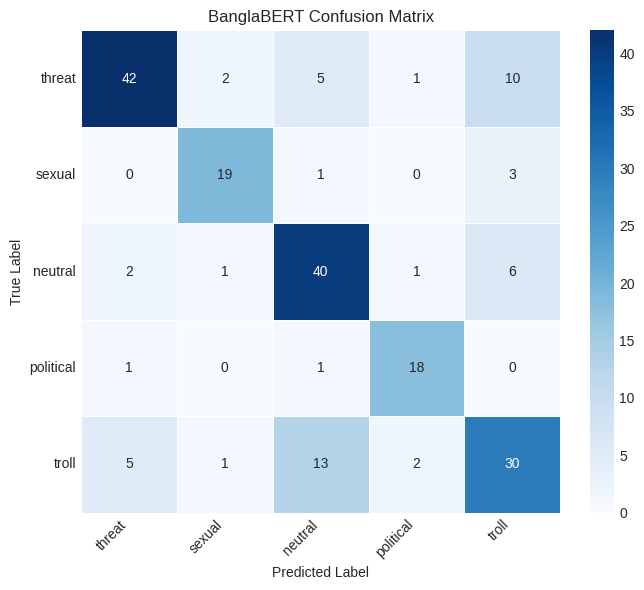

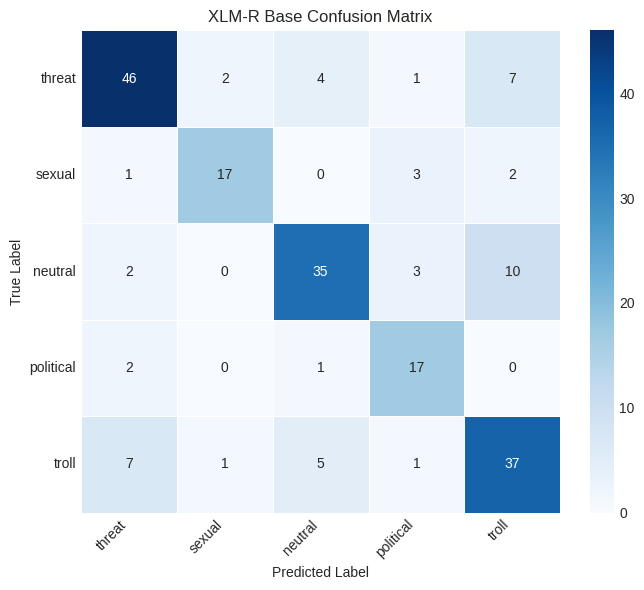

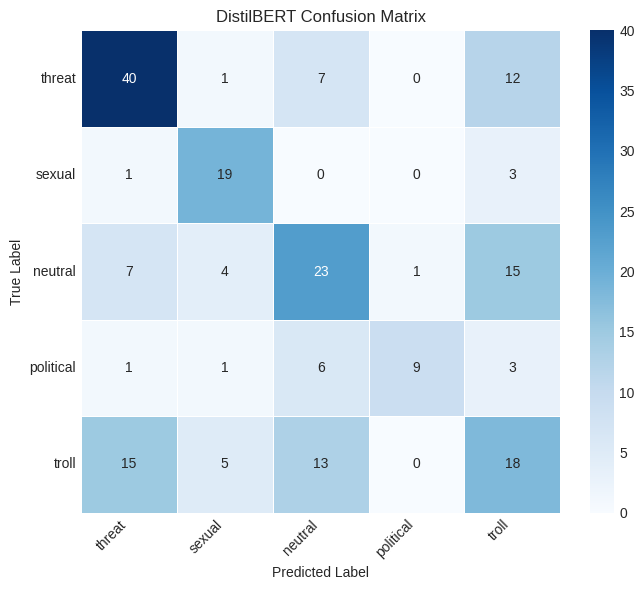

In [84]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# CLASS NAMES
# ==========================================
class_names = [
    "threat",
    "sexual",
    "neutral",
    "political",
    "troll",
]

# ==========================================
# PREDICTION FUNCTION
# ==========================================
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate(model, loader, name):
    y_true, y_pred = predict(model, loader)

    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall   : {r:.4f}")
    print(f"F1-score : {f1:.4f}")

    return acc, p, r, f1, cm

# ==========================================
# PAPER-STYLE CONFUSION MATRIX (BLUE HEATMAP)
# ==========================================
def plot_cm(cm, title):
    plt.style.use("seaborn-v0_8-white")  # clean paper style

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',          # 🔵 paper-style blue
        linewidths=0.5,
        linecolor='white',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )

    plt.title(title, fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

# ==========================================
# RUN EVALUATION
# ==========================================
bb = evaluate(model_bb, test_loader_bb, "BanglaBERT")
xlmr = evaluate(model_xlmr, test_loader_xlmr, "XLM-R Base")
distil = evaluate(model_distil, test_loader_distil, "DistilBERT")

# ==========================================
# FINAL COMPARISON TABLE
# ==========================================
results = pd.DataFrame([
    ["BanglaBERT", bb[0], bb[1], bb[2], bb[3]],
    ["XLM-R Base", xlmr[0], xlmr[1], xlmr[2], xlmr[3]],
    ["DistilBERT", distil[0], distil[1], distil[2], distil[3]],
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\n===== FINAL COMPARISON =====")
print(results)

# ==========================================
# CONFUSION MATRICES
# ==========================================
plot_cm(bb[4], "BanglaBERT Confusion Matrix")
plot_cm(xlmr[4], "XLM-R Base Confusion Matrix")
plot_cm(distil[4], "DistilBERT Confusion Matrix")

# Error Analysis

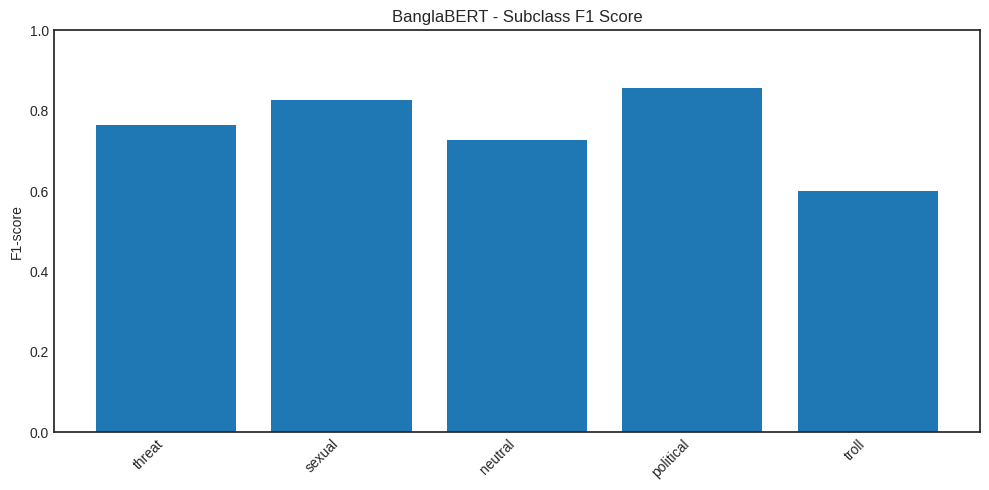

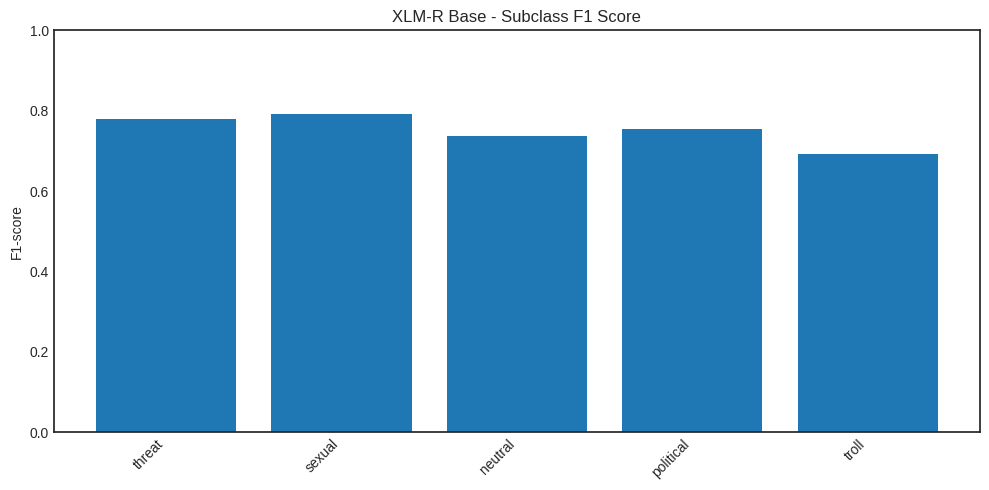

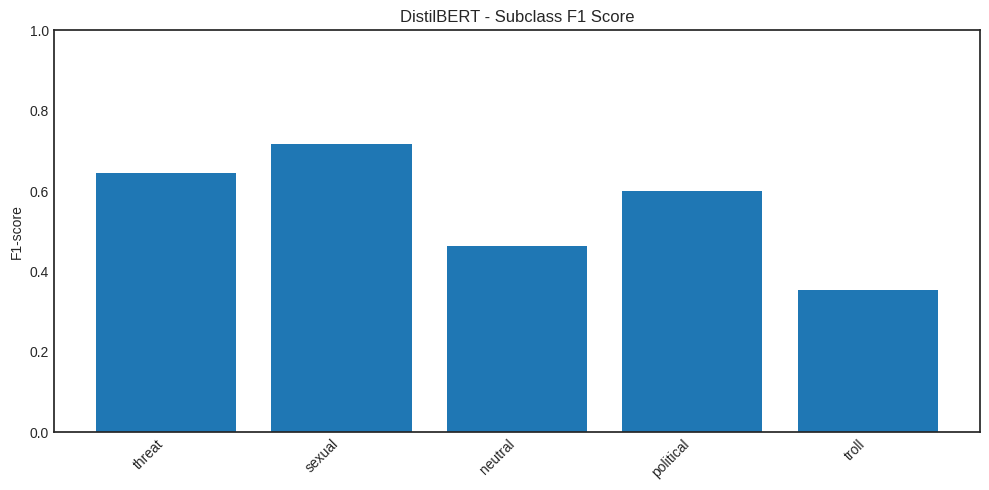

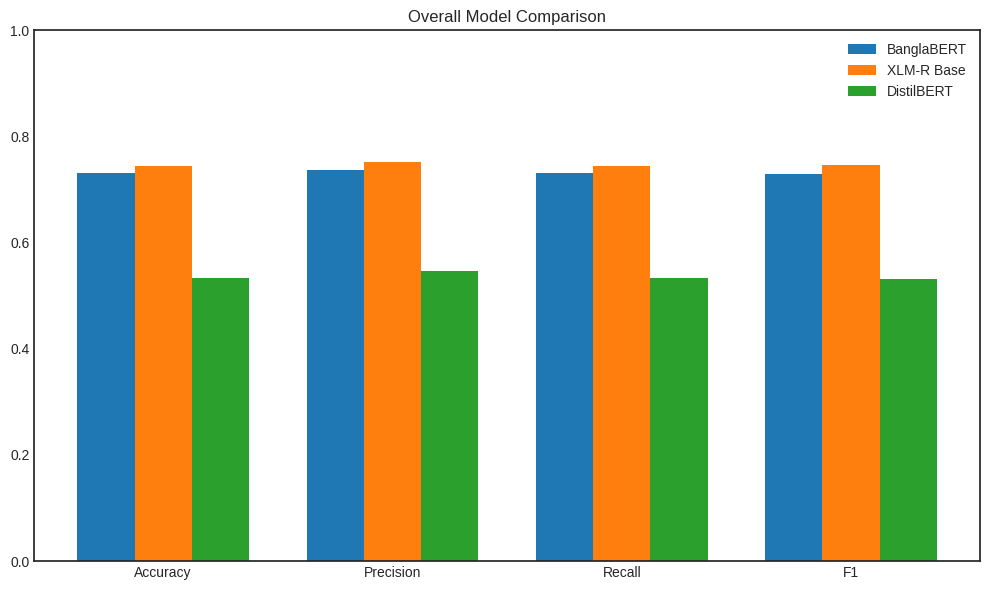

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# CLASS NAMES
# ==========================================
class_names = [
   "threat",
    "sexual",
    "neutral",
    "political",
    "troll",
]

# ==========================================
# PREDICTION FUNCTION
# (USE THIS IF NOT ALREADY CREATED)
# ==========================================
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


# ==========================================
# GET SUBCLASS REPORT
# ==========================================
def get_class_report(y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )
    return report


# ==========================================
# SUBCLASS F1 BAR CHART
# ==========================================
def plot_subclass_f1(report, title):
    f1_scores = [report[c]["f1-score"] for c in class_names]

    plt.figure(figsize=(10,5))
    plt.bar(class_names, f1_scores)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("F1-score")
    plt.tight_layout()
    plt.show()


# ==========================================
# MODEL PREDICTIONS
# ==========================================
y_true_bb, y_pred_bb = predict(model_bb, test_loader_bb)
y_true_xlmr, y_pred_xlmr = predict(model_xlmr, test_loader_xlmr)
y_true_distil, y_pred_distil = predict(model_distil, test_loader_distil)

# ==========================================
# REPORTS
# ==========================================
report_bb = get_class_report(y_true_bb, y_pred_bb)
report_xlmr = get_class_report(y_true_xlmr, y_pred_xlmr)
report_distil = get_class_report(y_true_distil, y_pred_distil)

# ==========================================
# 1️⃣ SUBCLASS PERFORMANCE (SEPARATE PLOTS)
# ==========================================
plot_subclass_f1(report_bb, "BanglaBERT - Subclass F1 Score")
plot_subclass_f1(report_xlmr, "XLM-R Base - Subclass F1 Score")
plot_subclass_f1(report_distil, "DistilBERT - Subclass F1 Score")


# ==========================================
# 2️⃣ OVERALL MODEL COMPARISON BAR CHART
# ==========================================
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return acc, p, r, f1


bb_metrics = get_metrics(y_true_bb, y_pred_bb)
xlmr_metrics = get_metrics(y_true_xlmr, y_pred_xlmr)
distil_metrics = get_metrics(y_true_distil, y_pred_distil)

metrics = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, bb_metrics, width, label="BanglaBERT")
plt.bar(x, xlmr_metrics, width, label="XLM-R Base")
plt.bar(x + width, distil_metrics, width, label="DistilBERT")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("Overall Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Logistic Regression

In [86]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val = val_df['Description'], val_df['label']
X_test, y_test = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit only on train
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform val + test
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# LOGISTIC REGRESSION
# ==========================================
clf = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight='balanced',
    n_jobs=-1
)

# Train
clf.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = clf.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = clf.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT (FIXED)
# ==========================================
class_names = le.classes_

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS (ADDED — SAME STYLE AS SVM)
# ==========================================
final_acc = test_acc
final_precision = test_precision
final_recall = test_recall
final_f1 = test_f1

print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + Logistic Regression)")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")


📊 VALIDATION PERFORMANCE
Accuracy : 0.5610
Precision: 0.5753
Recall   : 0.5610
F1-score : 0.5539

📊 TEST PERFORMANCE
Accuracy : 0.4657
Precision: 0.4667
Recall   : 0.4657
F1-score : 0.4651

🔹 Classification Report (Test):

              precision    recall  f1-score   support

     neutral       0.66      0.67      0.66        60
   political       0.31      0.35      0.33        23
      sexual       0.40      0.36      0.38        50
      threat       0.44      0.35      0.39        20
       troll       0.39      0.43      0.41        51

    accuracy                           0.47       204
   macro avg       0.44      0.43      0.43       204
weighted avg       0.47      0.47      0.47       204


🔥 FINAL MODEL PERFORMANCE (TF-IDF + Logistic Regression)
Accuracy : 0.4657
Precision: 0.4667
Recall   : 0.4657
F1-score : 0.4651


# SVM

In [91]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val = val_df['Description'], val_df['label']
X_test, y_test = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit only on train
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform val + test
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# SVM MODEL
# ==========================================
svm_clf = LinearSVC(
    C=1.0,
    class_weight='balanced'
)

# Train
svm_clf.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = svm_clf.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE (SVM)")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = svm_clf.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE (SVM)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT (FIXED)
# ==========================================
# Use LabelEncoder classes instead of hardcoded labels
class_names = le.classes_

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS
# ==========================================
final_acc = test_acc
final_precision = test_precision
final_recall = test_recall
final_f1 = test_f1

print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + SVM)")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")


📊 VALIDATION PERFORMANCE (SVM)
Accuracy : 0.5122
Precision: 0.5174
Recall   : 0.5122
F1-score : 0.5018

📊 TEST PERFORMANCE (SVM)
Accuracy : 0.4657
Precision: 0.4623
Recall   : 0.4657
F1-score : 0.4605

🔹 Classification Report (Test):

              precision    recall  f1-score   support

     neutral       0.57      0.65      0.60        60
   political       0.37      0.30      0.33        23
      sexual       0.40      0.38      0.39        50
      threat       0.54      0.35      0.42        20
       troll       0.41      0.45      0.43        51

    accuracy                           0.47       204
   macro avg       0.46      0.43      0.44       204
weighted avg       0.46      0.47      0.46       204


🔥 FINAL MODEL PERFORMANCE (TF-IDF + SVM)
Accuracy : 0.4657
Precision: 0.4623
Recall   : 0.4657
F1-score : 0.4605


# Multinomial Naive Bayes

In [96]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val     = val_df['Description'], val_df['label']
X_test, y_test   = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF (LIGHTWEIGHT)
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# ==========================================
# MODEL (NAIVE BAYES)
# ==========================================
nb_model = MultinomialNB()

# ==========================================
# TRAIN
# ==========================================
nb_model.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = nb_model.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE (Naive Bayes)")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = nb_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE (Naive Bayes)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================
class_names = [
   "threat",
    "sexual",
    "neutral",
    "political",
    "troll",
]

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS
# ==========================================
print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + Naive Bayes)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


📊 VALIDATION PERFORMANCE (Naive Bayes)
Accuracy : 0.5122
Precision: 0.4940
Recall   : 0.5122
F1-score : 0.4735

📊 TEST PERFORMANCE (Naive Bayes)
Accuracy : 0.4265
Precision: 0.3342
Recall   : 0.4265
F1-score : 0.3706

🔹 Classification Report (Test):

              precision    recall  f1-score   support

      threat       0.49      0.73      0.59        60
      sexual       0.00      0.00      0.00        23
     neutral       0.42      0.38      0.40        50
   political       0.00      0.00      0.00        20
       troll       0.35      0.47      0.40        51

    accuracy                           0.43       204
   macro avg       0.25      0.32      0.28       204
weighted avg       0.33      0.43      0.37       204


🔥 FINAL MODEL PERFORMANCE (TF-IDF + Naive Bayes)
Accuracy : 0.4265
Precision: 0.3342
Recall   : 0.4265
F1-score : 0.3706


# DL Models

In [97]:
# ==========================================
# CNN, BiLSTM, Hybrid MODEL (FINAL CLEAN VERSION)
# Bangla Cyberbullying Classification
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, MaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("/kaggle/input/datasets/maimaumme/bangla-cyberbullying/pattern lab dataset.xlsx")

df.columns = df.columns.str.strip()

# ==========================================
# CLEAN DATA (VERY IMPORTANT FIX)
# ==========================================
df = df.dropna(subset=["Label"])
df = df.dropna(subset=["Description"])

df["Label"] = df["Label"].astype(str).str.strip().str.lower()
df["Description"] = df["Description"].astype(str).str.strip()

print("Classes BEFORE encoding:", df["Label"].unique())
print("Number of classes:", df["Label"].nunique())


# ==========================================
# ENCODE LABELS
# ==========================================
le = LabelEncoder()
y = le.fit_transform(df["Label"])
X = df["Description"]


# ==========================================
# TRAIN / VAL / TEST SPLIT (SAFE)
# ==========================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


# ==========================================
# TOKENIZATION
# ==========================================
max_words = 20000
max_len = 150
embedding_dim = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding="post")


num_classes = len(np.unique(y_train))
print("Final number of classes:", num_classes)


# ==========================================
# CLASS WEIGHTS (IMPORTANT)
# ==========================================
classes = np.unique(y_train)
class_weights = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y_train)))


# ==========================================
# EARLY STOPPING
# ==========================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# ==========================================
# MODEL BUILDER
# ==========================================
def create_model(model_type="cnn"):
    inp = Input(shape=(max_len,))

    x = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len,
        trainable=True
    )(inp)

    if model_type == "cnn":
        x = Conv1D(128, 5, activation="relu")(x)
        x = GlobalMaxPooling1D()(x)

    elif model_type == "bilstm":
        x = Bidirectional(LSTM(64))(x)

    elif model_type == "hybrid":
        x = Conv1D(128, 5, activation="relu", padding="same")(x)
        x = MaxPooling1D(2)(x)
        x = Bidirectional(LSTM(64))(x)

    x = Dropout(0.5)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate(model, name):
    pred = np.argmax(model.predict(X_test_pad), axis=1)

    acc = accuracy_score(y_test, pred)

    p, r, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="weighted", zero_division=0
    )

    print(f"\n===== {name.upper()} =====")
    print("Accuracy:", acc)
    print("Precision:", p)
    print("Recall:", r)
    print("F1:", f1)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        pred,
        target_names=[str(c) for c in le.classes_],
        zero_division=0
    ))

    return acc, p, r, f1


# ==========================================
# TRAIN MODELS (EPOCH = 20 ✅)
# ==========================================
results = []

for name in ["cnn", "bilstm", "hybrid"]:
    print("\nTraining:", name.upper())

    model = create_model(name)

    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,          # 🔥 YOU ASKED FOR 20
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )

    results.append((name, *evaluate(model, name)))


# ==========================================
# FINAL RESULTS
# ==========================================
print("\nFINAL RESULTS")
print(pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"]))

2026-04-14 06:38:53.143234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776148733.375307      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776148733.449734      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776148734.008785      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776148734.008809      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776148734.008812      55 computation_placer.cc:177] computation placer alr

Classes BEFORE encoding: ['sexual' 'threat' 'political' 'troll' 'neutral']
Number of classes: 5
Final number of classes: 5

Training: CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1776148754.528049      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4535 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776148754.533391      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1776148757.145360     734 service.cc:152] XLA service 0x7f3adc2f1520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776148757.145404     734 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776148757.145408     734 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776148757.434641     734 cuda_dnn.cc:529] Loaded cuDNN version 91002


...

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.2039 - loss: 1.5981 - val_accuracy: 0.2941 - val_loss: 1.5877
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3606 - loss: 1.5829 - val_accuracy: 0.3137 - val_loss: 1.5546
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5710 - loss: 1.4183 - val_accuracy: 0.3922 - val_loss: 1.4676
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7603 - loss: 1.0927 - val_accuracy: 0.5490 - val_loss: 1.3037
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8644 - loss: 0.7286 - val_accuracy: 0.5980 - val_loss: 1.1313
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9451 - loss: 0.3214 - val_accuracy: 0.5980 - val_loss: 1.0145
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9776 - loss: 0.1553 - val_accuracy: 0.5980 - val_loss: 1.0939
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9937 - loss: 0.0741 - val_accuracy: 0.6176 - val_loss: 1.0230
E

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.1849 - loss: 1.6197 - val_accuracy: 0.2843 - val_loss: 1.5849
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3701 - loss: 1.6120 - val_accuracy: 0.2843 - val_loss: 1.5549
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3635 - loss: 1.4759 - val_accuracy: 0.4216 - val_loss: 1.4019
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6330 - loss: 1.0713 - val_accuracy: 0.4216 - val_loss: 1.2693
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7803 - loss: 0.6071 - val_accuracy: 0.4804 - val_loss: 1.1806
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9066 - loss: 0.2718 - val_accuracy: 0.4706 - val_loss: 1.6939
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9596 - loss: 0.1514 - val_accuracy: 0.5980 - val_loss: 1.2834
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9864 - loss: 0.0576 - val_accuracy: 0.6569 - val_loss: 1.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2265 - loss: 1.6119 - val_accuracy: 0.1863 - val_loss: 1.6005
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2214 - loss: 1.6161 - val_accuracy: 0.3529 - val_loss: 1.5075
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3770 - loss: 1.3258 - val_accuracy: 0.3431 - val_loss: 1.3666
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6633 - loss: 0.7182 - val_accuracy: 0.4510 - val_loss: 1.4666
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8593 - loss: 0.3347 - val_accuracy: 0.5882 - val_loss: 1.4924
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9800 - loss: 0.0873 - val_accuracy: 0.6176 - val_loss: 1.5964
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f39967ddc60> triggered tf.function retracing. Tracing is expensive a